# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [1]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

DATA_ZIP = Path("/content/drive/MyDrive/Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Mounted at /content/drive
Extracted: Flower Classification.zip -> data/flower_data
Candidate dataset roots: ['data/flower_data/Data', 'data/flower_data/Data/train', 'data/flower_data/Data/val']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [2]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: provided_split Base: data/flower_data/Data


In [3]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [4]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

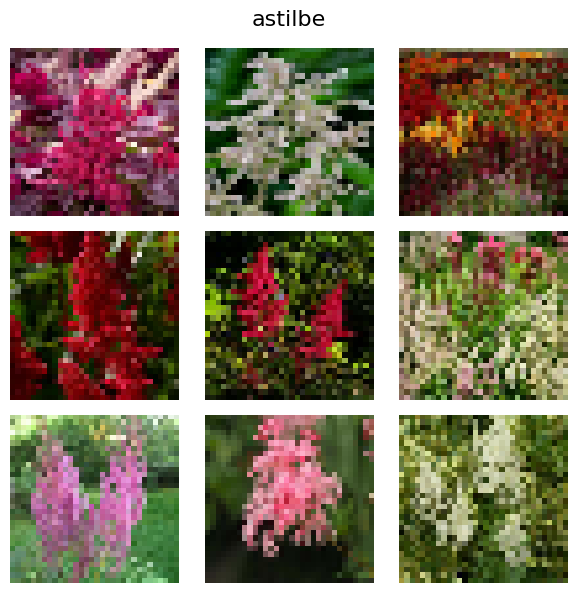

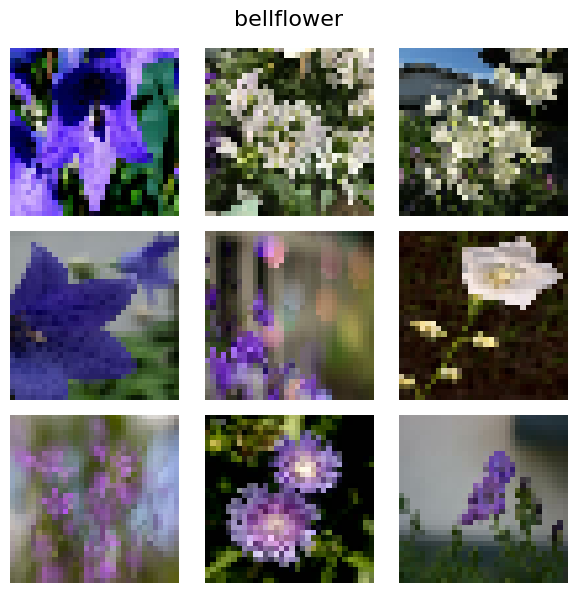

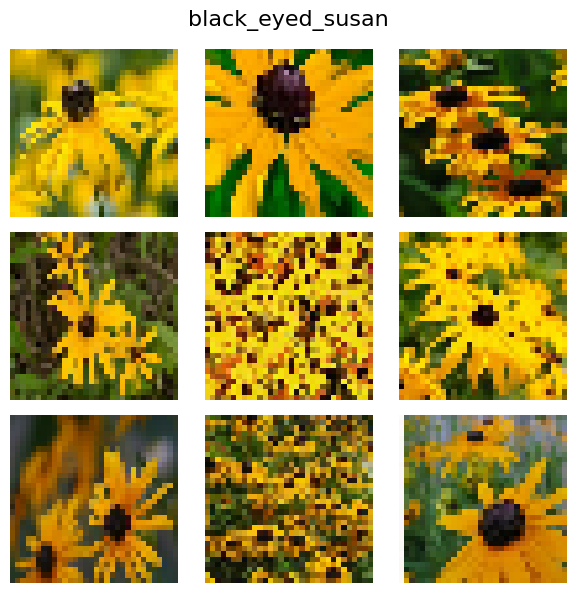

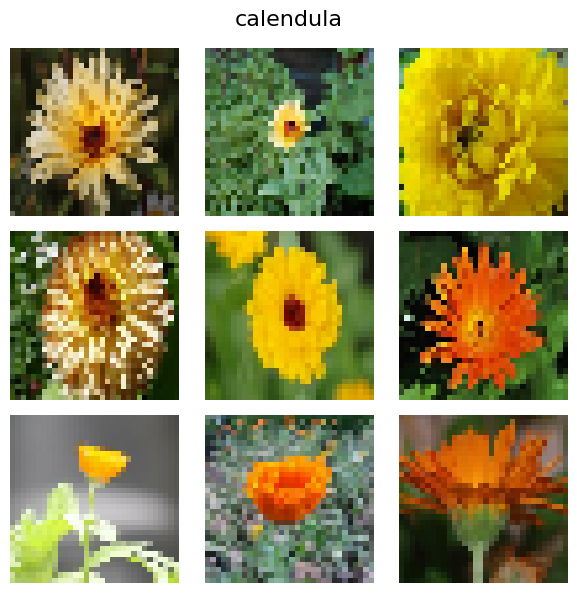

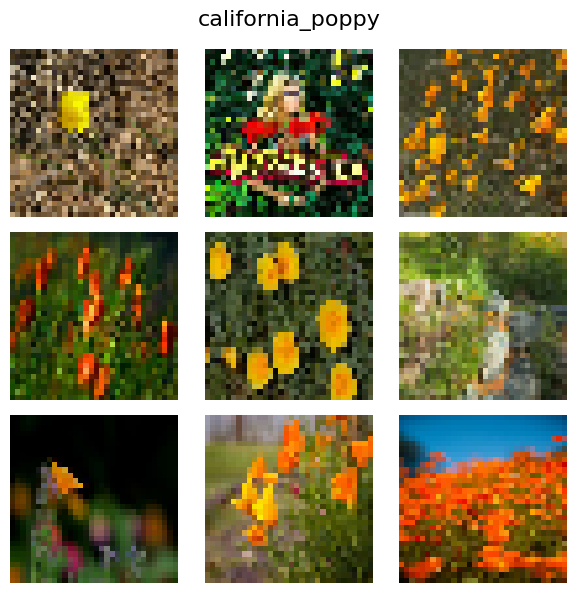

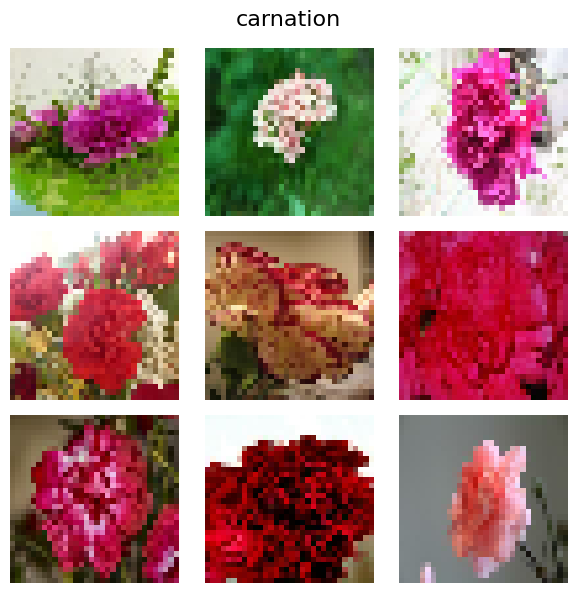

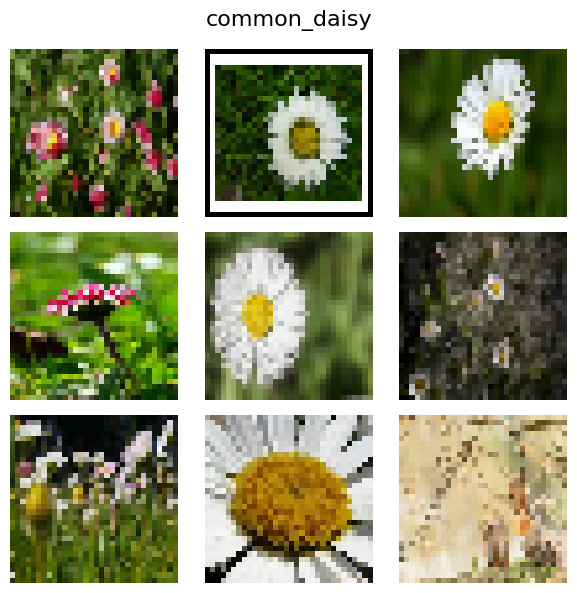

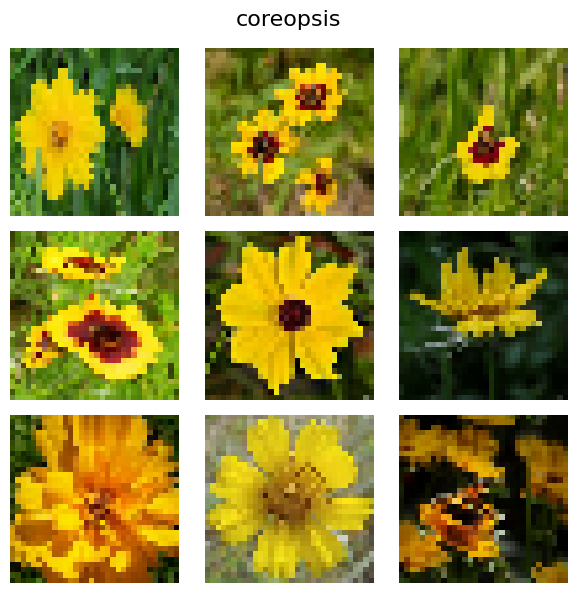

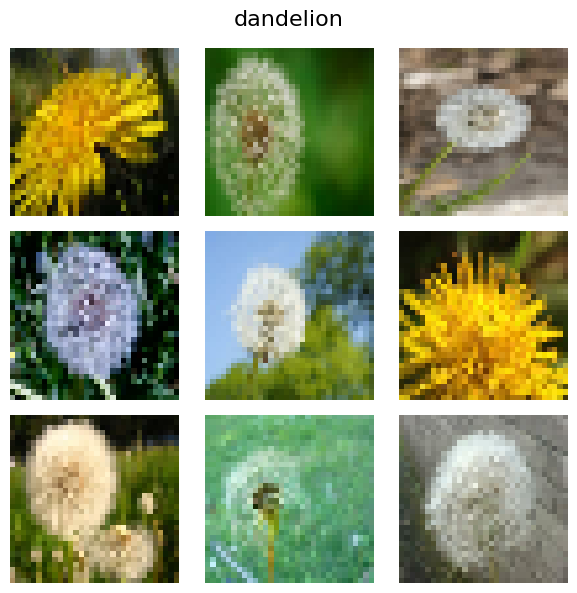

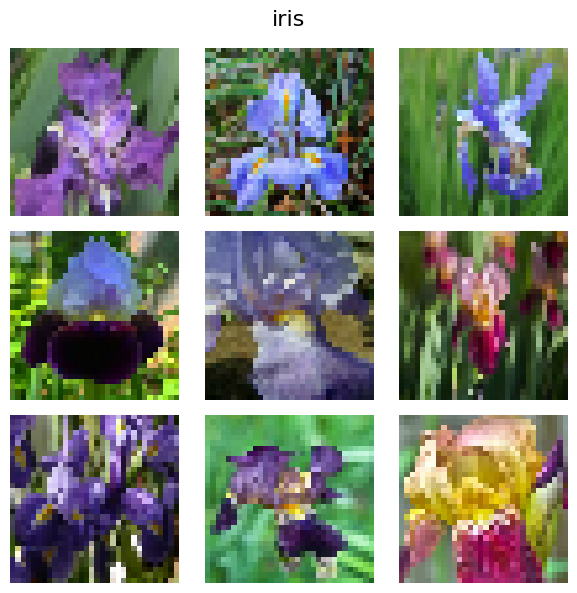

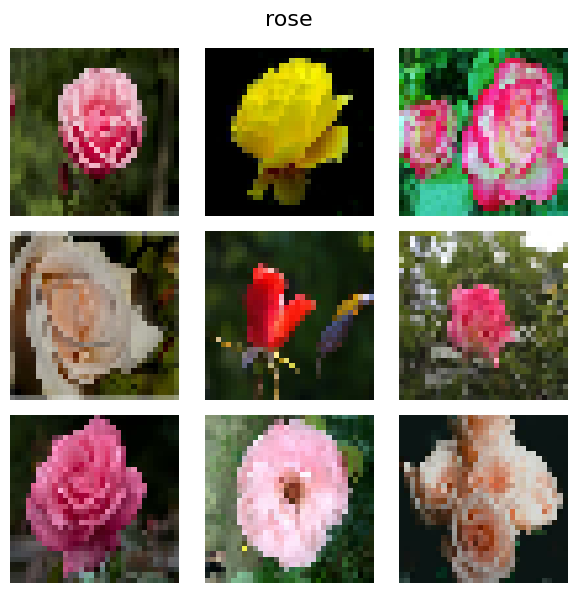

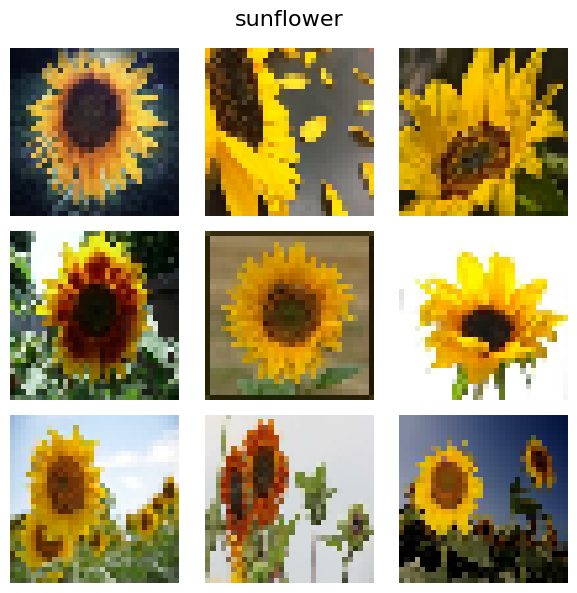

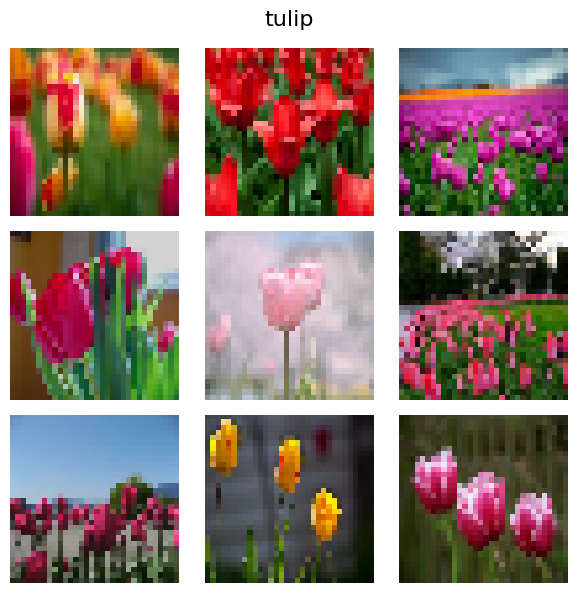

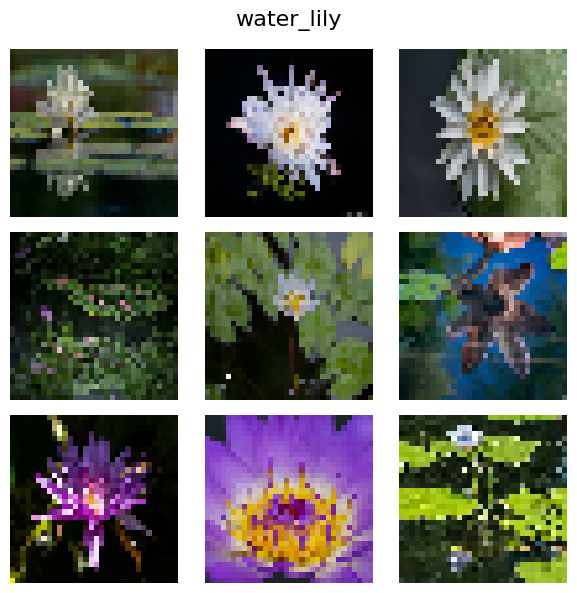

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_images(dataset, class_names, per_class=9):
    images_by_class = {i: [] for i in range(len(class_names))}

    # collect 9 images for each class
    for images, labels in dataset:
        for img, label in zip(images, labels):
            label = int(label.numpy())
            if len(images_by_class[label]) < per_class:
                images_by_class[label].append(img.numpy().astype("uint8"))

        # stop when every class has 9 images
        if all(len(images_by_class[i]) >= per_class for i in images_by_class):
            break

    # plot 3x3 grid for each class
    for class_index, class_name in enumerate(class_names):
        imgs = images_by_class[class_index]

        plt.figure(figsize=(6, 6))
        plt.suptitle(class_name, fontsize=16)

        for i in range(min(per_class, len(imgs))):
            plt.subplot(3, 3, i + 1)
            plt.imshow(imgs[i])
            plt.axis("off")

        plt.tight_layout()
        plt.show()

visualize_images(train_ds, class_names, per_class=9)

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.

Flower classification can be challenging because many classes share similar color palettes, such as yellow, white, or purple petals, which makes them visually difficult to distinguish. There is significant intra-class variation, as images of the same flower can differ in lighting, background, angle and stage of growth. Some images include complex backgrounds like grass or soil, which may distract the model from focusing on the flower itself. Another challenge is the low image resolution (32x32), which removes fine details that could help differentiate between classes. There may also be class imbalance, where some flower types have more images than others, leading the model to favor more frequent classes. These factors make it harder for the model to generalize well across all categories.


**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [6]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,326 (1.36 MB)

 Trainable params: 357,326 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# To-Do: create an improved architecture variant
# Suggestions:
# - Add BatchNormalization after Conv2D or Dense
# - Try kernel sizes 5x5 in early layers
# - Increase filters progressively 32->64->128->256
# - Adjust Dropout to 0.4
# def build_variant(num_classes):
#     pass
# model_variant = build_variant(num_classes)
# model_variant.summary()

def build_variant(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (5, 5), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_variant = build_variant(num_classes)
model_variant.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,998 (2.63 MB)

 Trainable params: 688,526 (2.63 MB)

 Non-trainable params: 1,472 (5.75 KB)

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.

The model increases the number of filters progressively from 32 to 256, allowing it to learn simple features such as edges first and then more complex patterns like flower shapes. The use of a 5x5 kernel in the first convolutional layer helps increase the receptive field early, capturing broader spatial information. Max pooling layers reduce the spatial dimensions step by step, keeping important features while lowering computational cost. Batch Normalization is applied after convolutional and dense layers to stabilize training and improve convergence speed. Dropout layers with higher rates (0.4 and 0.3) are used to prevent overfitting and improve generalization. This architecture balances feature extraction, training stability and regularization, leading to better performance than the baseline model.

## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [8]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# To-Do: run a few experiments
# Example search space
# Do: run a few experiments

opts = [
    ("adam", 1e-3, 32),
    ("adam", 5e-4, 32),
    ("rmsprop", 1e-3, 32),
    ("sgd", 1e-2, 64),
]

results = []

for opt_name, lr, batch in opts:
    print(f"\nRunning: {opt_name}, lr={lr}, batch={batch}")

    # rebuild model each time
    model = build_variant(num_classes)

    # choose optimizer
    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # early stopping
    cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history, dt = fit_model(model, train_ds, val_ds, epochs=8, callbacks=[cb])

    best_val = max(history.history["val_accuracy"])

    results.append({
        "opt": opt_name,
        "lr": lr,
        "batch": batch,
        "best_val_acc": float(best_val),
        "time_s": round(dt, 1)
    })

# show results
for r in results:
    print(r)


Running: adam, lr=0.001, batch=32
Epoch 1/8
427/427 - 24s - 56ms/step - accuracy: 0.3607 - loss: 1.9793 - val_accuracy: 0.2857 - val_loss: 1.8651
Epoch 2/8
427/427 - 2s - 5ms/step - accuracy: 0.5044 - loss: 1.4398 - val_accuracy: 0.3265 - val_loss: 2.5386
Epoch 3/8
427/427 - 2s - 5ms/step - accuracy: 0.5837 - loss: 1.2068 - val_accuracy: 0.5306 - val_loss: 1.4438
Epoch 4/8
427/427 - 2s - 4ms/step - accuracy: 0.6354 - loss: 1.0613 - val_accuracy: 0.6122 - val_loss: 1.1625
Epoch 5/8
427/427 - 2s - 4ms/step - accuracy: 0.6813 - loss: 0.9296 - val_accuracy: 0.5510 - val_loss: 1.4369
Epoch 6/8
427/427 - 2s - 4ms/step - accuracy: 0.7214 - loss: 0.8083 - val_accuracy: 0.5918 - val_loss: 1.2671
Epoch 7/8
427/427 - 2s - 4ms/step - accuracy: 0.7610 - loss: 0.6983 - val_accuracy: 0.6122 - val_loss: 1.1038
Epoch 8/8
427/427 - 2s - 4ms/step - accuracy: 0.7906 - loss: 0.6081 - val_accuracy: 0.6939 - val_loss: 1.1944

Running: adam, lr=0.0005, batch=32
Epoch 1/8
427/427 - 16s - 38ms/step - accuracy:

In [15]:
best = max(results, key=lambda x: x["best_val_acc"])
print("\nBest configuration:", best)


Best configuration: {'opt': 'adam', 'lr': 0.001, 'batch': 32, 'best_val_acc': 0.6938775777816772, 'time_s': 36.9}


**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.

The best hyperparameter combination was Adam optimizer with a learning rate of 0.001 and batch size 32. This model achieved the highest validation accuracy, about 0.69. Adam likely worked well because it adapts the learning rate during training, which helps the model converge faster and more stably. The batch size of 32 gave a good balance between speed and generalization. Compared with RMSprop and SGD, Adam produced better validation accuracy on this flower dataset. This combination seems suitable because the dataset has many visual differences between classes, but also similar colors and shapes, so stable optimization is important.

## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Found 10919 images belonging to 14 classes.
Found 2723 images belonging to 14 classes.
Epoch 1/8
342/342 - 36s - 104ms/step - accuracy: 0.3172 - loss: 2.1591 - val_accuracy: 0.0749 - val_loss: 4.0613
Epoch 2/8
342/342 - 27s - 78ms/step - accuracy: 0.4283 - loss: 1.6494 - val_accuracy: 0.2872 - val_loss: 2.0534
Epoch 3/8
342/342 - 23s - 67ms/step - accuracy: 0.4983 - loss: 1.4498 - val_accuracy: 0.4227 - val_loss: 1.7392
Epoch 4/8
342/342 - 22s - 64ms/step - accuracy: 0.5346 - loss: 1.3253 - val_accuracy: 0.5483 - val_loss: 1.3653
Epoch 5/8
342/342 - 24s - 69ms/step - accuracy: 0.5711 - loss: 1.2475 - val_accuracy: 0.5813 - val_loss: 1.2119
Epoch 6/8
342/342 - 21s - 61ms/step - accuracy: 0.6044 - loss: 1.1529 - val_accuracy: 0.5549 - val_loss: 1.2749
Epoch 7/8
342/342 - 22s - 64ms/step - accuracy: 0.6227 - loss: 1.1062 - val_accuracy: 0.6284 - val_loss: 1.1015
Epoch 8/8
342/342 - 21s - 61ms/step - accuracy: 0.6324 - loss: 1.0637 - val_accuracy: 0.5340 - val_loss: 1.3958


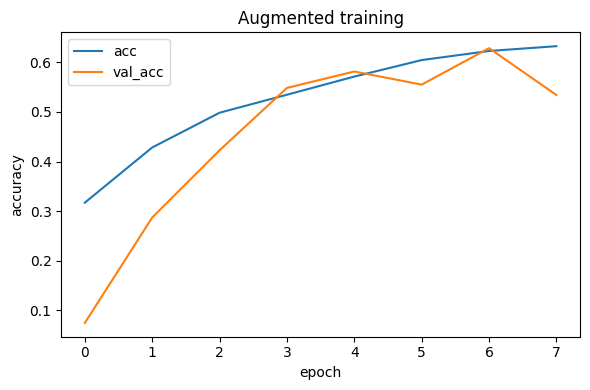

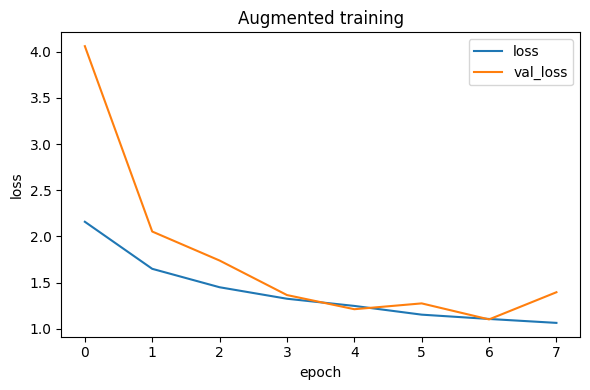

In [18]:
# To-Do: build an ImageDataGenerator pipeline (Option A)
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# model_aug = build_baseline(num_classes)  # or your variant
# hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=8, verbose=2)
# plot_curves(hist_aug, title='Augmented training')

from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = next((p for p in Path(base).iterdir() if p.name.lower()=="train"), None)

if train_dir is None:
    train_dir = base

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

flow_train = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="sparse", subset="training", seed=SEED)

flow_val   = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="sparse", subset="validation", seed=SEED)

model_aug = build_variant(num_classes)

history_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=8, verbose=2)

plot_curves(history_aug, title="Augmented training")

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.

Data augmentation improved the model by increasing the diversity of the training data. Transformations such as rotation, shifting and zoom helped the model become more robust to changes in orientation and position of the flowers. Horizontal flipping was useful because many flowers look similar when flipped. These augmentations reduce overfitting by preventing the model from memorizing specific images. The model generalizes better to new unseen data. The most helpful augmentations were rotation and zoom, as they simulate real variations in how flowers appear in images.

## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [11]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

                  precision    recall  f1-score   support

         astilbe      0.000     0.000     0.000         7
      bellflower      0.000     0.000     0.000         7
black_eyed_susan      0.368     1.000     0.538         7
       calendula      0.667     0.286     0.400         7
california_poppy      1.000     0.143     0.250         7
       carnation      0.000     0.000     0.000         7
    common_daisy      0.149     1.000     0.259         7
       coreopsis      0.000     0.000     0.000         7
       dandelion      0.000     0.000     0.000         7
            iris      0.000     0.000     0.000         7
            rose      0.000     0.000     0.000         7
       sunflower      0.833     0.714     0.769         7
           tulip      0.238     0.714     0.357         7
      water_lily      0.000     0.000     0.000         7

        accuracy                          0.276        98
       macro avg      0.233     0.276     0.184        98
    weighted

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


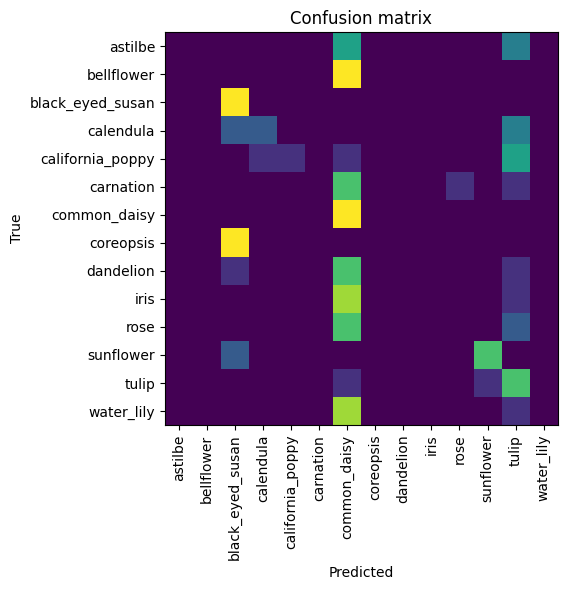

In [19]:
# To-Do: evaluate your best model on val_ds

best_model = model_aug
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
plot_confusion(cm, class_names)

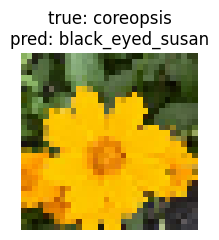

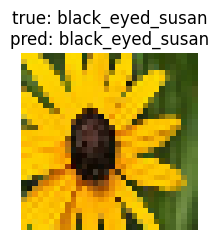

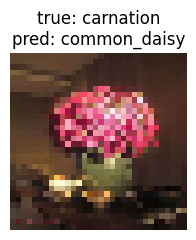

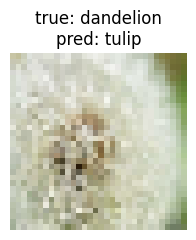

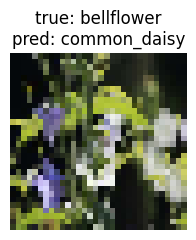

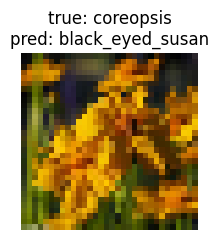

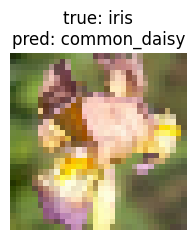

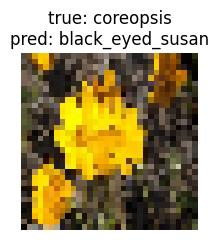

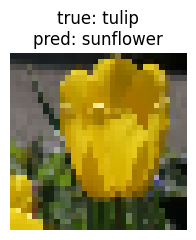

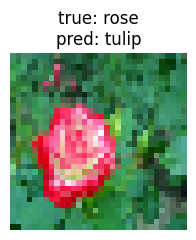

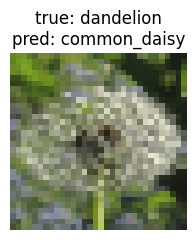

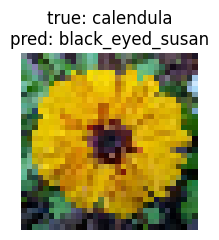

In [21]:
# To-Do: visualize a few predictions and inspect errors
import random
take = 12
imgs, labels = next(iter(val_ds.unbatch().batch(take)))
probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)
for i in range(take):
    plt.figure(figsize=(2.5,2.5))
    plt.imshow(imgs[i].numpy().astype('uint8'))
    t = f"true: {class_names[int(labels[i])]}\npred: {class_names[int(preds[i])]}"
    plt.title(t)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.

The model performed better on some flower classes than others. The most difficult classes were those with similar colors and shapes, especially flowers with yellow, white, or purple petals. Some mistakes may also be caused by small image size, because resizing to 32x32 removes fine details such as petal texture and flower center structure. Background and lighting differences can also confuse the model when the flower is not clearly separated from the image background. The confusion matrix helps identify which classes are often mixed up and shows where the model needs improvement. Model learned useful visual patterns, but similar morphology and limited image resolution still caused misclassifications.


## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [26]:
best_model.save("./data/flower_cnn.h5")
print("Saved to ./data/flower_cnn.h5")

Saved to ./data/flower_cnn.h5
